<a href="https://colab.research.google.com/github/chandBadal/AI_ML/blob/main/2431248_Badal_Chand_Part_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ── Imports
import pandas as pd
import numpy as np
import re
import time
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

!pip install contractions --quiet
import contractions

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from imblearn.over_sampling import RandomOverSampler

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM,
                                      Bidirectional, Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

!pip install gensim --quiet
import gensim.downloader as api

nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)

print('TensorFlow:', tf.__version__)
print('All imports successful.')


TensorFlow: 2.20.0
All imports successful.


In [ ]:
# ── Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2 · Load Dataset

In [ ]:
# ── File paths ───────────────────────────────────────────────────
TRAIN_FILE = '/content/drive/MyDrive/AI-ML/data/7. Racist Sexist or Not Dataset/train_racisit.csv'
TEST_FILE  = '/content/drive/MyDrive/AI-ML/data/7. Racist Sexist or Not Dataset/test_racisit.csv'

train_data = pd.read_csv(TRAIN_FILE)
test_data  = pd.read_csv(TEST_FILE)

print('Train shape:', train_data.shape)
print('Test  shape:', test_data.shape)
print()
print(train_data.head())


Train shape: (31962, 3)
Test  shape: (17197, 2)

   id  label                                              tweet
0   1      0   @user when a father is dysfunctional and is s...
1   2      0  @user @user thanks for #lyft credit i can't us...
2   3      0                                bihday your majesty
3   4      0  #model   i love u take with u all the time in ...
4   5      0             factsguide: society now    #motivation


In [ ]:
print('Column names  :', train_data.columns.tolist())
print('Missing values:\n', train_data.isnull().sum())
print()
print('Class counts:')
print(train_data['label'].value_counts())
print()
print('Class percentages:')
print(train_data['label'].value_counts(normalize=True).mul(100).round(2))

Column names  : ['id', 'label', 'tweet']
Missing values:
 id       0
label    0
tweet    0
dtype: int64

Class counts:
label
0    29720
1     2242
Name: count, dtype: int64

Class percentages:
label
0    92.99
1     7.01
Name: proportion, dtype: float64


## 3 · Exploratory Data Analysis

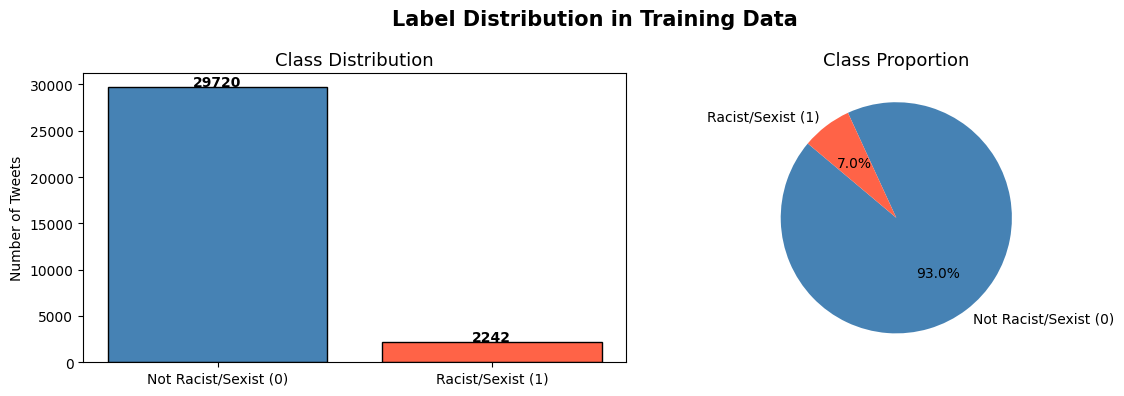

Imbalance ratio: 13.3 : 1


In [ ]:
# ── Bar chart + Pie chart
class_counts = train_data['label'].value_counts()
class_labels = {0: 'Not Racist/Sexist (0)', 1: 'Racist/Sexist (1)'}

figure, (plot1, plot2) = plt.subplots(1, 2, figsize=(12, 4))

plot1.bar([class_labels[l] for l in class_counts.index],
          class_counts.values,
          color=['steelblue', 'tomato'], edgecolor='black')
plot1.set_title('Class Distribution', fontsize=13)
plot1.set_ylabel('Number of Tweets')
for pos, val in enumerate(class_counts.values):
    plot1.text(pos, val + 100, str(val), ha='center', fontweight='bold')

plot2.pie(class_counts.values,
          labels=[class_labels[l] for l in class_counts.index],
          autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=140)
plot2.set_title('Class Proportion', fontsize=13)

plt.suptitle('Label Distribution in Training Data', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

imbalance_ratio = class_counts[0] / class_counts[1]
print(f'Imbalance ratio: {imbalance_ratio:.1f} : 1')

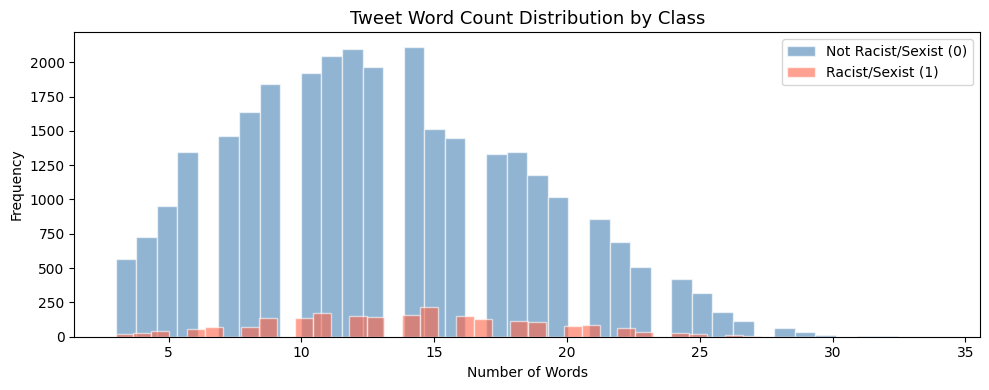

         count       mean       std  min   25%   50%   75%   max
label                                                           
0      29720.0  13.091252  5.510082  3.0   9.0  13.0  17.0  34.0
1       2242.0  14.053078  4.950747  3.0  10.0  14.0  17.0  30.0


In [ ]:
# ── Tweet length histogram
train_data['num_words'] = train_data['tweet'].apply(lambda t: len(str(t).split()))

plt.figure(figsize=(10, 4))
for lbl, colour in zip([0, 1], ['steelblue', 'tomato']):
    word_counts = train_data[train_data['label'] == lbl]['num_words']
    plt.hist(word_counts, bins=40, alpha=0.6,
             color=colour, label=class_labels[lbl], edgecolor='white')

plt.title('Tweet Word Count Distribution by Class', fontsize=13)
plt.xlabel('Number of Words'); plt.ylabel('Frequency'); plt.legend()
plt.tight_layout(); plt.show()

print(train_data.groupby('label')['num_words'].describe())

## 4 · Text Preprocessing

In [ ]:
english_stopwords = set(stopwords.words('english'))
text_lemmatizer   = WordNetLemmatizer()

def clean_single_tweet(tweet_text):
    """
    Preprocess a single tweet:
    - lowercase, expand contractions, remove URLs/mentions/hashtags,
    - strip special chars, remove stopwords, lemmatize.
    """
    cleaned = str(tweet_text).lower()
    cleaned = contractions.fix(cleaned)
    cleaned = re.sub(r'http\S+|www\S+|https\S+', '', cleaned, flags=re.MULTILINE)
    cleaned = re.sub(r'@\w+', '', cleaned)
    cleaned = re.sub(r'#(\w+)', r'\1', cleaned)
    cleaned = re.sub(r'\brt\b', '', cleaned)
    cleaned = re.sub(r'[^a-z\s]', '', cleaned)

    word_tokens = cleaned.split()
    filtered    = [
        text_lemmatizer.lemmatize(word)
        for word in word_tokens
        if word not in english_stopwords and len(word) > 1
    ]
    return ' '.join(filtered)

train_data['processed_tweet'] = train_data['tweet'].apply(clean_single_tweet)
test_data['processed_tweet']  = test_data['tweet'].apply(clean_single_tweet)

pd.set_option('display.max_colwidth', 120)
print('Cleaning complete. Sample:')
train_data[['tweet', 'processed_tweet']].sample(5, random_state=1)

Cleaning complete. Sample:


,tweet,processed_tweet
266,i'll probably be 30 by the time @user comes back home #ugh,probably time come back home ugh
20460,just finished recoding my audition for abc dicovers. #abcdiscovers #abc #actorslife #sagaftra,finished recoding audition abc dicovers abcdiscovers abc actorslife sagaftra
18133,"this will be dustin's bihday present, bihday dj,",dustins bihday present bihday dj
15417,"this is my ""do i really have to go to work face""!!!! #work #face #itsfriday #wanttosleep",really go work face work face itsfriday wanttosleep
3077,eat the all #muslm,eat muslm


# ── Overall word cloud ───────────────────────────────────────────
all_cleaned_text = ' '.join(train_data['processed_tweet'])

wordcloud_all = WordCloud(
    width=900, height=420,
    background_color='white',
    colormap='RdYlBu',
    max_words=150
).generate(all_cleaned_text)

plt.figure(figsize=(13, 5))
plt.imshow(wordcloud_all, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — All Cleaned Tweets', fontsize=14)
plt.tight_layout(); plt.show()

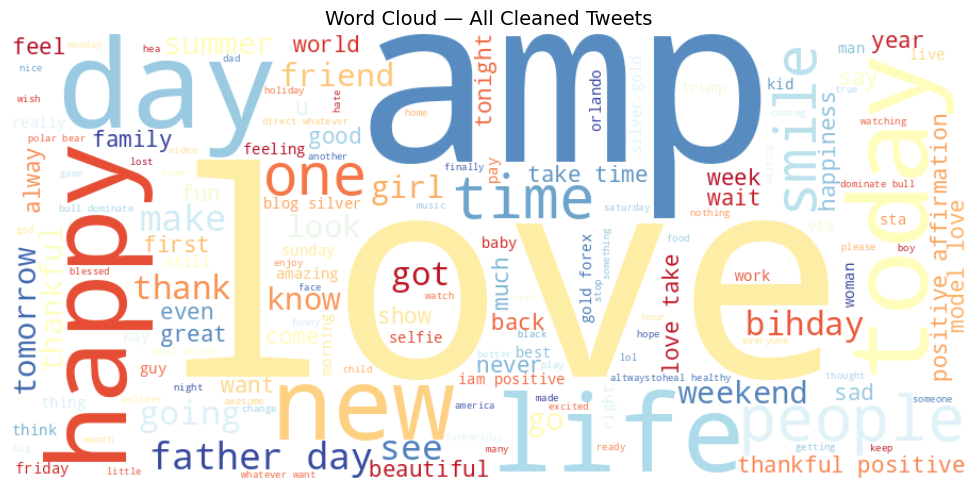

In [ ]:
# ── Overall word cloud
all_cleaned_text = ' '.join(train_data['processed_tweet'])

wordcloud_all = WordCloud(
    width=900, height=420,
    background_color='white',
    colormap='RdYlBu',
    max_words=150
).generate(all_cleaned_text)

plt.figure(figsize=(13, 5))
plt.imshow(wordcloud_all, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — All Cleaned Tweets', fontsize=14)
plt.tight_layout(); plt.show()

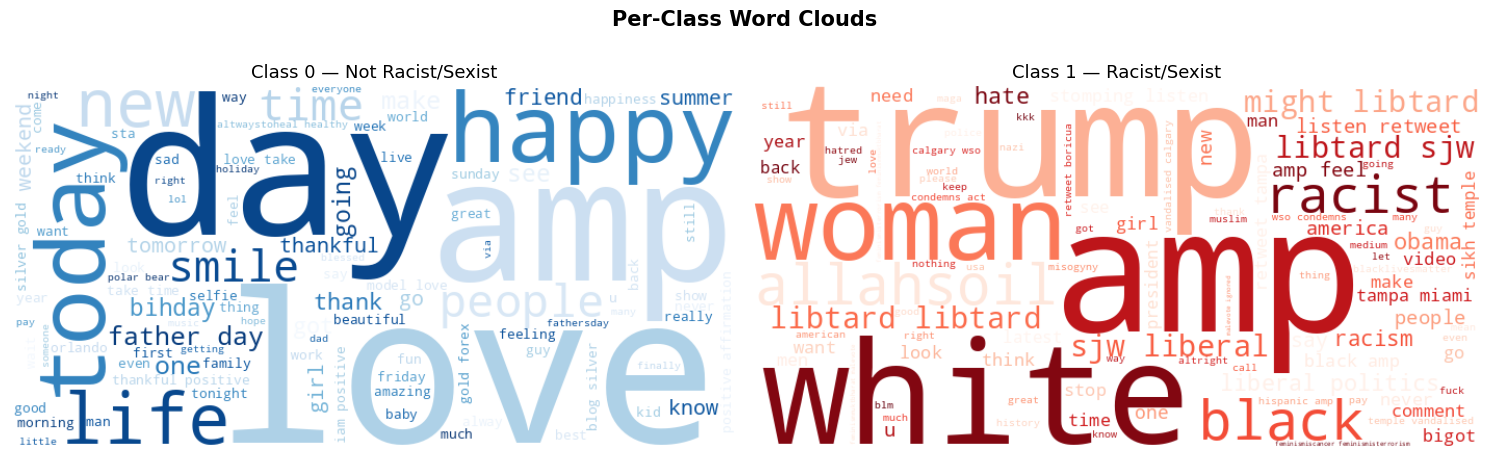

In [ ]:
# ── Per-class word clouds
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
configs = [(0, 'Blues', 'Class 0 — Not Racist/Sexist'),
           (1, 'Reds',  'Class 1 — Racist/Sexist')]

for ax, (lbl, colour_map, chart_title) in zip(axes, configs):
    class_text = ' '.join(train_data[train_data['label'] == lbl]['processed_tweet'])
    wc = WordCloud(width=700, height=350, background_color='white',
                   colormap=colour_map, max_words=100).generate(class_text)
    ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
    ax.set_title(chart_title, fontsize=13)

plt.suptitle('Per-Class Word Clouds', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

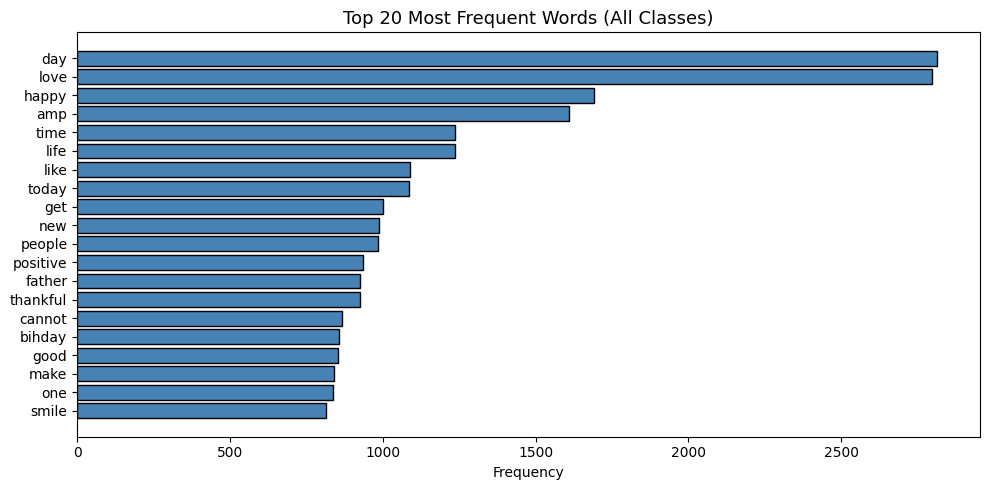

Top 20: [('day', 2813), ('love', 2796), ('happy', 1691), ('amp', 1608), ('time', 1235), ('life', 1235), ('like', 1088), ('today', 1086), ('get', 1000), ('new', 988), ('people', 985), ('positive', 935), ('father', 925), ('thankful', 925), ('cannot', 867), ('bihday', 856), ('good', 853), ('make', 842), ('one', 837), ('smile', 813)]


In [ ]:
# ── Top-20 words bar chart
all_words_list  = all_cleaned_text.split()
top20           = Counter(all_words_list).most_common(20)
top_words, top_counts = zip(*top20)

plt.figure(figsize=(10, 5))
plt.barh(top_words[::-1], top_counts[::-1], color='steelblue', edgecolor='black')
plt.xlabel('Frequency')
plt.title('Top 20 Most Frequent Words (All Classes)', fontsize=13)
plt.tight_layout(); plt.show()
print('Top 20:', top20)


## 6 · Prepare Features & Labels

In [ ]:
RANDOM_STATE = 42 # Defined based on kernel state variable
tweet_corpus   = train_data['processed_tweet'].values
tweet_labels   = train_data['label'].values

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    tweet_corpus, tweet_labels,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=tweet_labels
)

print(f'Training samples : {len(X_train_raw)}')
print(f'Testing  samples : {len(X_test_raw)}')
print(f'Train label dist : {Counter(y_train_raw)}')
print(f'Test  label dist : {Counter(y_test_raw)}')


Training samples : 25569
Testing  samples : 6393
Train label dist : Counter({0: 23775, 1: 1794})
Test  label dist : Counter({0: 5945, 1: 448})


## 7 · Tokenisation & Sequence Padding

In [ ]:
VOCABULARY_SIZE = 10000
OUT_OF_VOCAB    = '<OOV>'

sequence_tokenizer = Tokenizer(
    num_words=VOCABULARY_SIZE,
    oov_token=OUT_OF_VOCAB,
    filters='!"#$%&()*+,-./:;<=>?@[\]^_`{|}~\t\n'
)
sequence_tokenizer.fit_on_texts(X_train_raw)

train_int_seqs = sequence_tokenizer.texts_to_sequences(X_train_raw)
test_int_seqs  = sequence_tokenizer.texts_to_sequences(X_test_raw)

seq_length_list = [len(s) for s in train_int_seqs]

# Ensure seq_length_list is not empty to avoid error with np.percentile
# If it is empty, it indicates no tokens were generated, which is a major issue.
# For now, setting a default to avoid immediate crash, but this scenario needs investigation.
if not seq_length_list:
    print("Warning: No tokens generated for training data. Setting SEQUENCE_LENGTH to a default of 20.")
    SEQUENCE_LENGTH = 20 # Fallback default
    max_raw_length = 0
    pct_covered = 0.0
else:
    SEQUENCE_LENGTH = int(np.percentile(seq_length_list, 95))
    if SEQUENCE_LENGTH == 0: # If 95th percentile is 0, implying all or most sequences are very short
        SEQUENCE_LENGTH = 1 # Ensure minimum length for padding
    max_raw_length = max(seq_length_list)
    pct_covered     = sum(1 for s in seq_length_list if s <= SEQUENCE_LENGTH) / len(seq_length_list)

print(f'Vocabulary size   : {len(sequence_tokenizer.word_index):,}')
print(f'Sequence length   : {SEQUENCE_LENGTH}  ({pct_covered:.1%} coverage)')
print(f'Max raw length    : {max_raw_length}')

X_train_seq = pad_sequences(train_int_seqs, maxlen=SEQUENCE_LENGTH, padding='post', truncating='post')
X_test_seq  = pad_sequences(test_int_seqs,  maxlen=SEQUENCE_LENGTH, padding='post', truncating='post')

print(f'X_train_seq shape : {X_train_seq.shape}')
print(f'X_test_seq  shape : {X_test_seq.shape}')

<>:7: SyntaxWarning: invalid escape sequence '\]'
<>:7: SyntaxWarning: invalid escape sequence '\]'
/tmp/ipykernel_21350/3012145665.py:7: SyntaxWarning: invalid escape sequence '\]'
  filters='!"#$%&()*+,-./:;<=>?@[\]^_`{|}~\t\n'


Vocabulary size   : 32,104
Sequence length   : 13  (97.1% coverage)
Max raw length    : 20
X_train_seq shape : (25569, 13)
X_test_seq  shape : (6393, 13)


## 8 · Handle Class Imbalance

Before resampling: Counter({0: 23775, 1: 1794})
After  resampling: Counter({0: 23775, 1: 23775})
New training size : 47,550


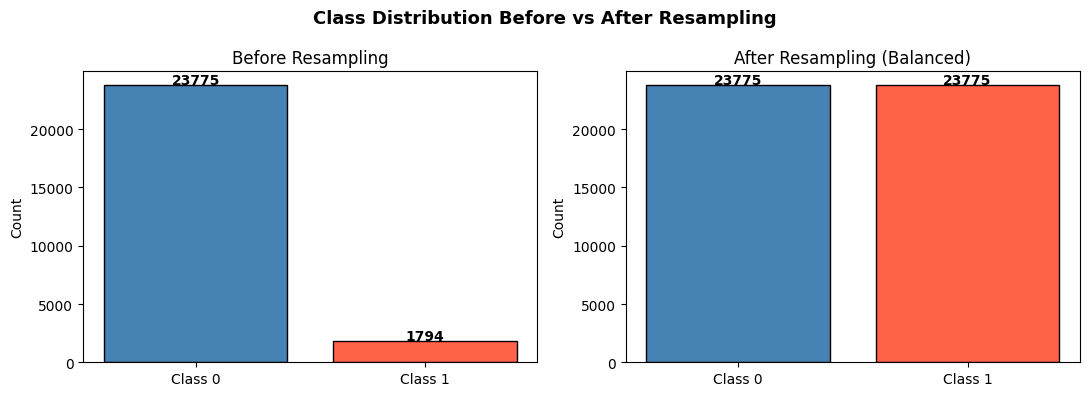

In [ ]:
print('Before resampling:', Counter(y_train_raw))

ros_sampler = RandomOverSampler(sampling_strategy='auto', random_state=RANDOM_STATE)
X_resampled_data, y_resampled_labels = ros_sampler.fit_resample(X_train_seq, y_train_raw)

print('After  resampling:', Counter(y_resampled_labels))
print(f'New training size : {len(X_resampled_data):,}')

fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(11, 4))
for ax, cnt, title_txt in zip(
        [ax_before, ax_after],
        [Counter(y_train_raw), Counter(y_resampled_labels)],
        ['Before Resampling', 'After Resampling (Balanced)']):
    ax.bar(['Class 0', 'Class 1'], [cnt[0], cnt[1]],
           color=['steelblue', 'tomato'], edgecolor='black')
    ax.set_title(title_txt, fontsize=12); ax.set_ylabel('Count')
    for idx_bar, count_val in enumerate([cnt[0], cnt[1]]):
        ax.text(idx_bar, count_val + 100, str(count_val), ha='center', fontweight='bold')

plt.suptitle('Class Distribution Before vs After Resampling', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## 9 · Load FastText Pretrained Embeddings

In [ ]:
print('Downloading FastText embeddings (300-d) …')
pretrained_embeddings = api.load('fasttext-wiki-news-subwords-300')
PRETRAINED_DIM = 300
print(f'Loaded. Total vocab: {len(pretrained_embeddings.key_to_index):,}')

Loaded. Total vocab: 999,999


In [ ]:
pretrained_matrix = np.zeros((VOCABULARY_SIZE, PRETRAINED_DIM))
words_found = 0

for vocab_word, vocab_idx in sequence_tokenizer.word_index.items():
    if vocab_idx < VOCABULARY_SIZE and vocab_word in pretrained_embeddings:
        pretrained_matrix[vocab_idx] = pretrained_embeddings[vocab_word]
        words_found += 1

total_possible = min(VOCABULARY_SIZE, len(sequence_tokenizer.word_index))
coverage_rate  = words_found / total_possible
print(f'Words matched: {words_found:,} / {total_possible:,}  ({coverage_rate:.1%})')


Words matched: 7,921 / 10,000  (79.2%)


## 10 · Model Building & Training
### Shared Config

In [ ]:
EMBEDDING_UNITS = 128
OUTPUT_UNITS    = 1
BATCH_SIZE_VAL  = 64
MAX_EPOCH_COUNT = 30

training_duration = {}

# Stratified train/val split from resampled data
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
for train_idx, val_idx in splitter.split(X_resampled_data, y_resampled_labels):
    X_fit  = X_resampled_data[train_idx]
    X_val  = X_resampled_data[val_idx]
    y_fit  = y_resampled_labels[train_idx]
    y_val  = y_resampled_labels[val_idx]

print(f'Fit set  : {X_fit.shape}  |  Val set : {X_val.shape}')


Fit set  : (38040, 13)  |  Val set : (9510, 13)


In [ ]:
def draw_training_curves(history_obj, model_title):
    """Visualise accuracy and loss over epochs."""
    epoch_range = range(1, len(history_obj.history['accuracy']) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epoch_range, history_obj.history['accuracy'],     'bo-', label='Train Acc')
    plt.plot(epoch_range, history_obj.history['val_accuracy'], 'ro-', label='Val   Acc')
    plt.title(f'{model_title} — Accuracy', fontsize=12)
    plt.xlabel('Epoch'); plt.ylabel('Accuracy')
    plt.legend(); plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epoch_range, history_obj.history['loss'],     'bo-', label='Train Loss')
    plt.plot(epoch_range, history_obj.history['val_loss'], 'ro-', label='Val   Loss')
    plt.title(f'{model_title} — Loss', fontsize=12)
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.legend(); plt.grid(True)

    plt.tight_layout(); plt.show()


def run_model_evaluation(trained_model, test_X, test_y, model_title, decision_threshold=0.5):
    """Print classification report and confusion matrix."""
    eval_loss, eval_acc = trained_model.evaluate(test_X, test_y, verbose=0)

    print(f'\n{"="*60}')
    print(f'  Evaluation: {model_title}')
    print(f'{"="*60}')
    print(f'Accuracy : {eval_acc:.4f}  |  Loss : {eval_loss:.4f}')

    raw_probs  = trained_model.predict(test_X, verbose=0).flatten()
    class_preds = (raw_probs >= decision_threshold).astype(int)

    print('\nClassification Report:')
    print(classification_report(
        test_y, class_preds,
        target_names=['Not Racist/Sexist', 'Racist/Sexist'],
        digits=4))

    conf_mat = confusion_matrix(test_y, class_preds)
    fig, axis = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(
        conf_mat,
        display_labels=['Not Racist/Sexist', 'Racist/Sexist']
    ).plot(cmap='Blues', ax=axis)
    axis.set_title(f'Confusion Matrix — {model_title}', fontsize=12)
    plt.tight_layout(); plt.show()

    return eval_acc, eval_loss

print('Helpers ready.')

Helpers ready.


### Model 1 · Simple RNN

In [ ]:
tf.random.set_seed(RANDOM_STATE)

simple_rnn_net = Sequential(name='SimpleRNN_Model')
simple_rnn_net.add(Embedding(input_dim=VOCABULARY_SIZE,
                              output_dim=EMBEDDING_UNITS,
                              input_length=SEQUENCE_LENGTH))
simple_rnn_net.add(SimpleRNN(64, return_sequences=False))
simple_rnn_net.add(Dropout(0.5))
simple_rnn_net.add(Dense(32, activation='relu'))
simple_rnn_net.add(Dense(OUTPUT_UNITS, activation='sigmoid'))

simple_rnn_net.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
simple_rnn_net.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop_rnn = EarlyStopping(monitor='val_loss', patience=3,
                                restore_best_weights=True, verbose=1)

start_time = time.time()
rnn_history = simple_rnn_net.fit(
    X_fit, y_fit,
    epochs=MAX_EPOCH_COUNT,
    batch_size=BATCH_SIZE_VAL,
    validation_data=(X_val, y_val),
    callbacks=[early_stop_rnn],
    verbose=1
)
training_duration['Model 1 – Simple RNN'] = time.time() - start_time
print(f'Training done in {training_duration["Model 1 – Simple RNN"]:.1f}s')


Epoch 1/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 30s 33ms/step - accuracy: 0.9385 - loss: 0.1494 - val_accuracy: 0.9837 - val_loss: 0.0425
Epoch 2/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.9927 - loss: 0.0218 - val_accuracy: 0.9835 - val_loss: 0.0603
Epoch 3/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.9944 - loss: 0.0156 - val_accuracy: 0.9818 - val_loss: 0.0595
Epoch 4/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.9957 - loss: 0.0127 - val_accuracy: 0.9830 - val_loss: 0.0715
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Training done in 79.8s


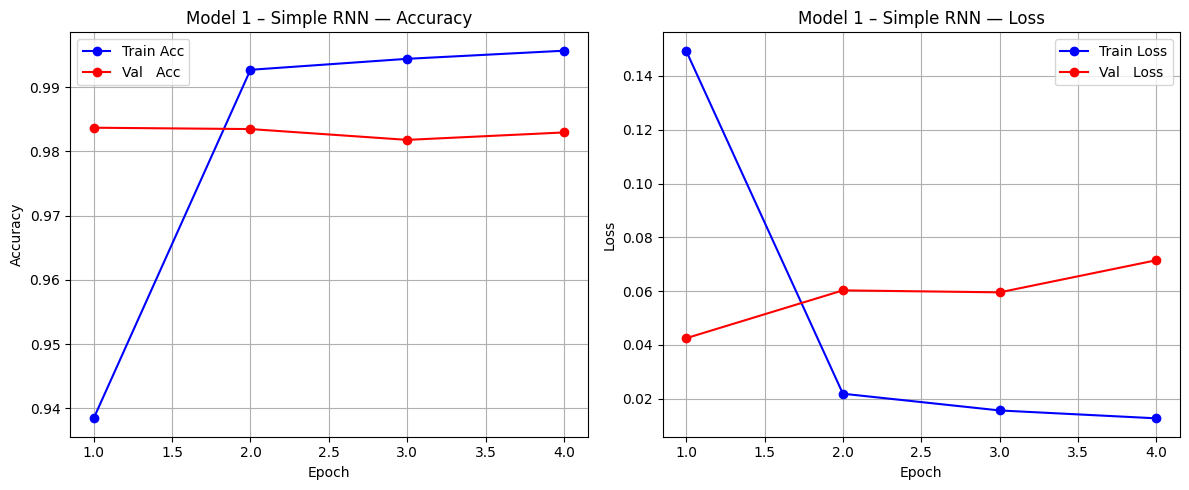


  Evaluation: Model 1 – Simple RNN
Accuracy : 0.9532  |  Loss : 0.1890

Classification Report:
                   precision    recall  f1-score   support

Not Racist/Sexist     0.9685    0.9817    0.9750      5945
    Racist/Sexist     0.7030    0.5759    0.6331       448

         accuracy                         0.9532      6393
        macro avg     0.8357    0.7788    0.8041      6393
     weighted avg     0.9499    0.9532    0.9511      6393



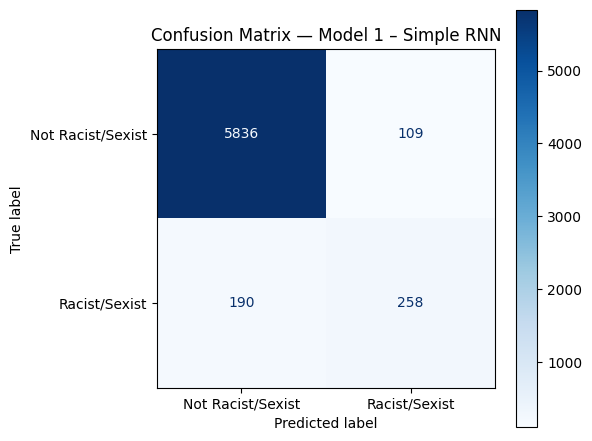

In [ ]:
draw_training_curves(rnn_history, 'Model 1 – Simple RNN')
result_acc1, result_loss1 = run_model_evaluation(
    simple_rnn_net, X_test_seq, y_test_raw, 'Model 1 – Simple RNN')


### Model 2 · LSTM with Trainable Embeddings

In [ ]:
tf.random.set_seed(RANDOM_STATE)

lstm_network = Sequential(name='LSTM_Model')
lstm_network.add(Embedding(input_dim=VOCABULARY_SIZE,
                            output_dim=EMBEDDING_UNITS,
                            input_length=SEQUENCE_LENGTH))
lstm_network.add(LSTM(64, return_sequences=False))
lstm_network.add(Dropout(0.3))
lstm_network.add(Dense(64, activation='relu'))
lstm_network.add(Dropout(0.3))
lstm_network.add(Dense(OUTPUT_UNITS, activation='sigmoid'))

lstm_network.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)
lstm_network.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop_lstm = EarlyStopping(monitor='val_loss', patience=5,
                                 restore_best_weights=True, verbose=1)
lr_scheduler_2  = ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                     patience=3, min_lr=1e-6, verbose=1)

start_time = time.time()
lstm_history = lstm_network.fit(
    X_fit, y_fit,
    epochs=MAX_EPOCH_COUNT,
    batch_size=BATCH_SIZE_VAL,
    validation_data=(X_val, y_val),
    callbacks=[early_stop_lstm, lr_scheduler_2],
    verbose=1
)
training_duration['Model 2 – LSTM'] = time.time() - start_time
print(f'Training done in {training_duration["Model 2 – LSTM"]:.1f}s')


Epoch 1/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.9065 - loss: 0.2172 - val_accuracy: 0.9718 - val_loss: 0.0824 - learning_rate: 5.0000e-04
Epoch 2/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - accuracy: 0.9820 - loss: 0.0571 - val_accuracy: 0.9695 - val_loss: 0.0995 - learning_rate: 5.0000e-04
Epoch 3/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 43s 41ms/step - accuracy: 0.9881 - loss: 0.0351 - val_accuracy: 0.9674 - val_loss: 0.1288 - learning_rate: 5.0000e-04
Epoch 4/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9896 - loss: 0.0306
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
595/595 ━━━━━━━━━━━━━━━━━━━━ 40s 40ms/step - accuracy: 0.9904 - loss: 0.0280 - val_accuracy: 0.9757 - val_loss: 0.1086 - learning_rate: 5.0000e-04
Epoch 5/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 39s 38ms/step - accuracy: 0.9955 - loss: 0.0137 - val_accuracy: 0.9783 - val_loss: 0.1092 - learning_rate: 1.5000e-04
Epoch 6/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 24s 41ms/step - ac

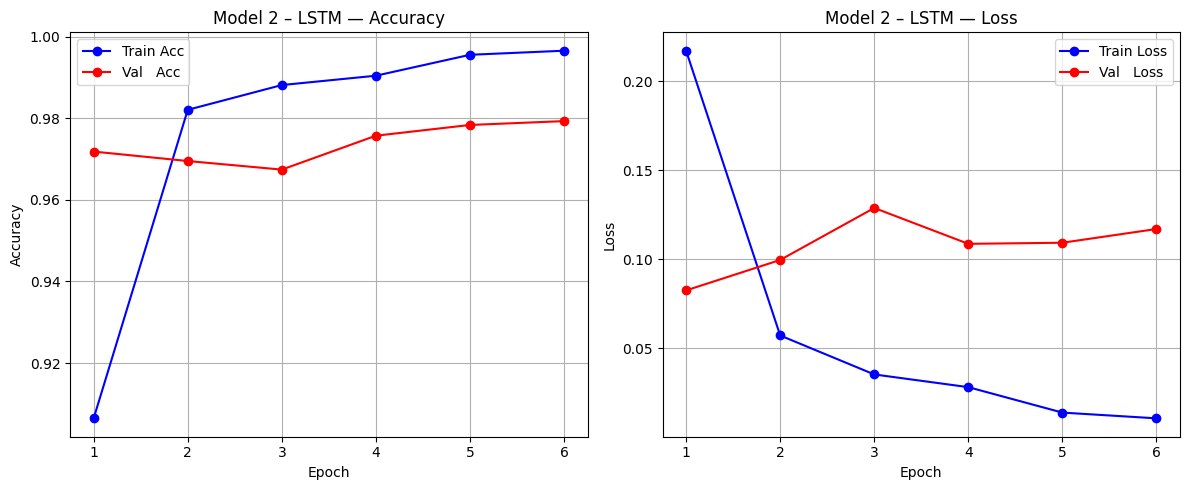


  Evaluation: Model 2 – LSTM
Accuracy : 0.9412  |  Loss : 0.1806

Classification Report:
                   precision    recall  f1-score   support

Not Racist/Sexist     0.9797    0.9566    0.9680      5945
    Racist/Sexist     0.5612    0.7366    0.6371       448

         accuracy                         0.9412      6393
        macro avg     0.7704    0.8466    0.8025      6393
     weighted avg     0.9503    0.9412    0.9448      6393



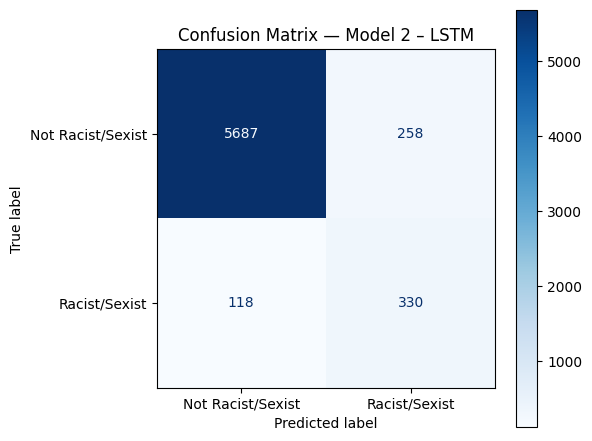

In [ ]:
draw_training_curves(lstm_history, 'Model 2 – LSTM')
result_acc2, result_loss2 = run_model_evaluation(
    lstm_network, X_test_seq, y_test_raw, 'Model 2 – LSTM')


### Model 3 · Bidirectional LSTM + FastText

In [ ]:
tf.random.set_seed(RANDOM_STATE)

bilstm_network = Sequential(name='BiLSTM_FastText_Model')
bilstm_network.add(Embedding(
    input_dim=VOCABULARY_SIZE,
    output_dim=PRETRAINED_DIM,
    weights=[pretrained_matrix],
    # input_length=SEQUENCE_LENGTH,  # Deprecated and removed
    trainable=False   # frozen pretrained weights
))
bilstm_network.add(Bidirectional(LSTM(128, return_sequences=False)))
bilstm_network.add(Dropout(0.3))
bilstm_network.add(Dense(128, activation='relu'))
bilstm_network.add(Dropout(0.3))
bilstm_network.add(Dense(OUTPUT_UNITS, activation='sigmoid'))

bilstm_network.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)
bilstm_network.summary()

Model: "BiLSTM_FastText_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,000,000 (11.44 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,000,000 (11.44 MB)

In [ ]:
early_stop_bi  = EarlyStopping(monitor='val_accuracy', patience=4,
                                restore_best_weights=True, verbose=1)
lr_scheduler_3 = ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                    patience=3, min_lr=1e-6, verbose=1)

class_weight_vals = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_fit
)
class_weight_dict = {0: class_weight_vals[0], 1: class_weight_vals[1]}
print('Class weights:', class_weight_dict)

start_time = time.time()
bilstm_history = bilstm_network.fit(
    X_fit, y_fit,
    epochs=MAX_EPOCH_COUNT,
    batch_size=BATCH_SIZE_VAL,
    validation_data=(X_val, y_val),
    callbacks=[early_stop_bi, lr_scheduler_3],
    class_weight=class_weight_dict,
    verbose=1
)
training_duration['Model 3 – BiLSTM + FastText'] = time.time() - start_time
print(f'Training done in {training_duration["Model 3 – BiLSTM + FastText"]:.1f}s')

Class weights: {0: 1.0, 1: 1.0}
Epoch 1/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 67s 102ms/step - accuracy: 0.8491 - loss: 0.3559 - val_accuracy: 0.8678 - val_loss: 0.3030 - learning_rate: 5.0000e-04
Epoch 2/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 76s 93ms/step - accuracy: 0.8828 - loss: 0.2736 - val_accuracy: 0.8885 - val_loss: 0.2574 - learning_rate: 5.0000e-04
Epoch 3/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 58s 97ms/step - accuracy: 0.9043 - loss: 0.2288 - val_accuracy: 0.9087 - val_loss: 0.2207 - learning_rate: 5.0000e-04
Epoch 4/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 81s 96ms/step - accuracy: 0.9191 - loss: 0.1963 - val_accuracy: 0.9119 - val_loss: 0.2048 - learning_rate: 5.0000e-04
Epoch 5/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 57s 96ms/step - accuracy: 0.9320 - loss: 0.1679 - val_accuracy: 0.9221 - val_loss: 0.1846 - learning_rate: 5.0000e-04
Epoch 6/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 59s 100ms/step - accuracy: 0.9419 - loss: 0.1448 - val_accuracy: 0.9354 - val_loss: 0.1723 - learning_rate: 5.0000e-04
Epoch 7/30
595/595

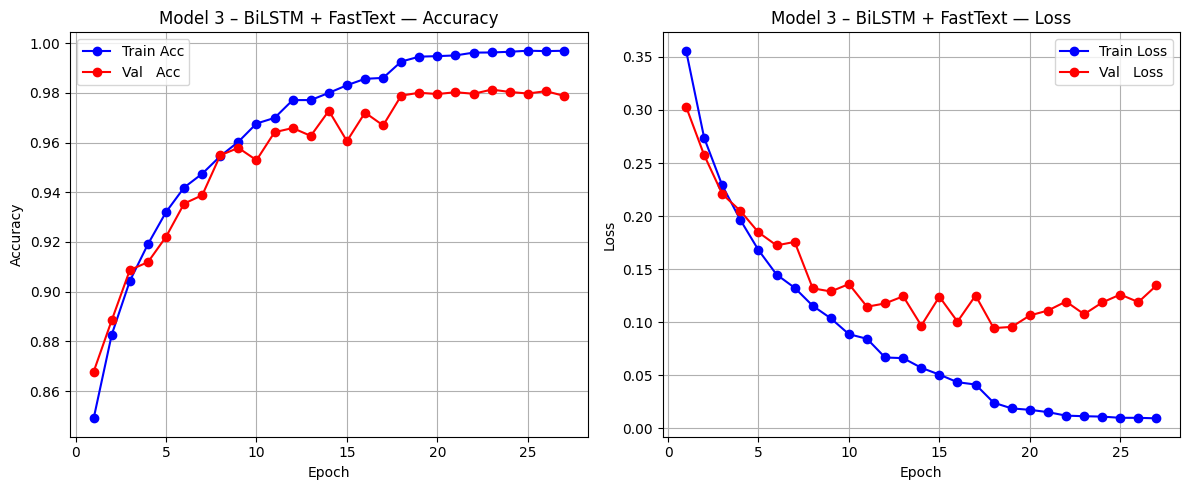


  Evaluation: Model 3 – BiLSTM + FastText
Accuracy : 0.3011  |  Loss : 0.6968

Classification Report:
                   precision    recall  f1-score   support

Not Racist/Sexist     0.9028    0.2671    0.4123      5945
    Racist/Sexist     0.0598    0.6183    0.1090       448

         accuracy                         0.2917      6393
        macro avg     0.4813    0.4427    0.2606      6393
     weighted avg     0.8437    0.2917    0.3910      6393



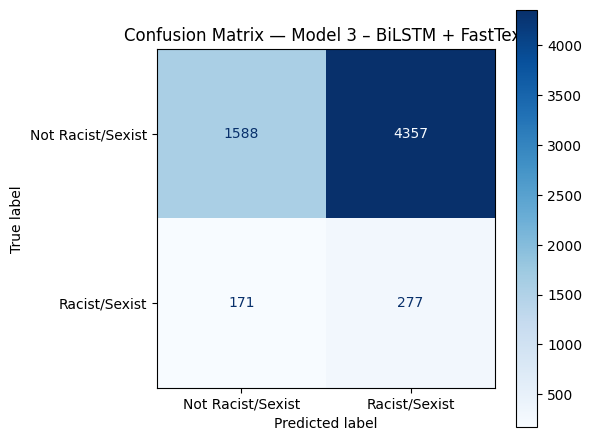

In [ ]:
draw_training_curves(bilstm_history, 'Model 3 – BiLSTM + FastText')
result_acc3, result_loss3 = run_model_evaluation(
    bilstm_network, X_test_seq, y_test_raw, 'Model 3 – BiLSTM + FastText')


## 11 · Final Model Comparison

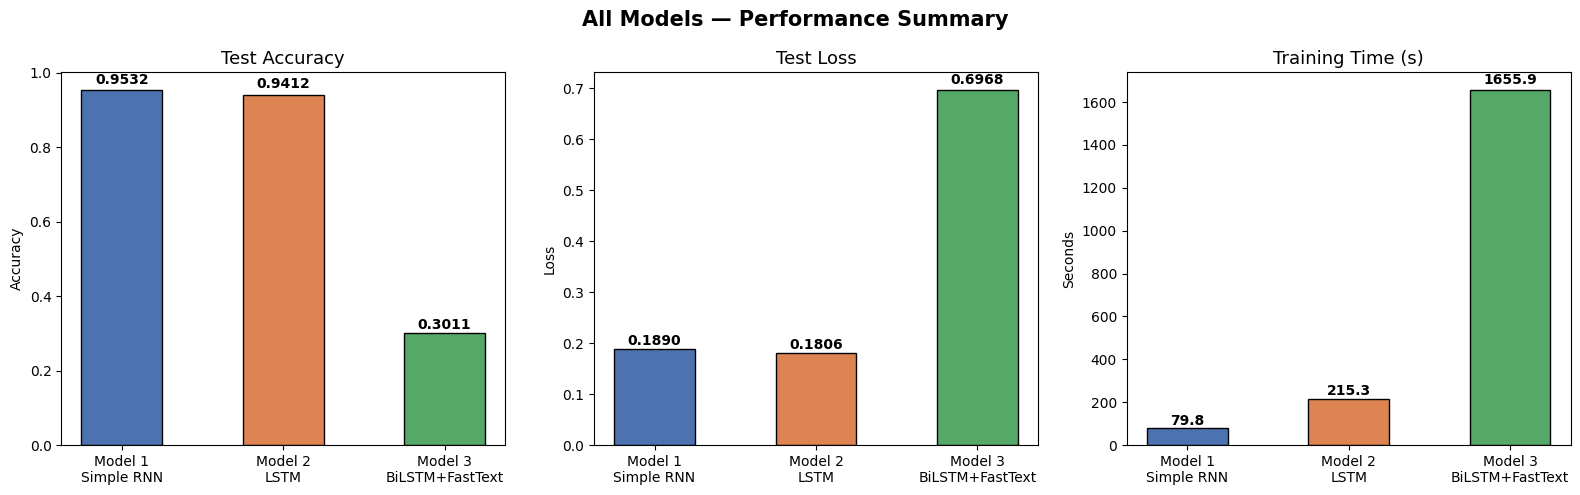


── Summary ───────────────────────────────────────────────
Model 1 – Simple RNN                 Acc=0.9532  Loss=0.1890  Time=1.33 min
Model 2 – LSTM                       Acc=0.9412  Loss=0.1806  Time=3.59 min
Model 3 – BiLSTM + FastText          Acc=0.3011  Loss=0.6968  Time=27.60 min


In [ ]:
all_model_names = [
    'Model 1\nSimple RNN',
    'Model 2\nLSTM',
    'Model 3\nBiLSTM+FastText'
]
all_accuracies = [result_acc1, result_acc2, result_acc3]
all_losses     = [result_loss1, result_loss2, result_loss3]
all_times      = list(training_duration.values())

fig, chart_axes = plt.subplots(1, 3, figsize=(16, 5))
bar_colours = ['#4C72B0', '#DD8452', '#55A868']

for ax, metric_vals, chart_title, y_label, num_fmt in zip(
        chart_axes,
        [all_accuracies, all_losses, all_times],
        ['Test Accuracy', 'Test Loss', 'Training Time (s)'],
        ['Accuracy', 'Loss', 'Seconds'],
        ['.4f', '.4f', '.1f']):
    bar_objs = ax.bar(all_model_names, metric_vals,
                      color=bar_colours, edgecolor='black', width=0.5)
    ax.set_title(chart_title, fontsize=13); ax.set_ylabel(y_label)
    for bar_obj, val in zip(bar_objs, metric_vals):
        ax.text(bar_obj.get_x() + bar_obj.get_width()/2,
                bar_obj.get_height() * 1.01,
                f'{val:{num_fmt}}', ha='center', va='bottom',
                fontweight='bold', fontsize=10)

plt.suptitle('All Models — Performance Summary', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

print('\n── Summary ───────────────────────────────────────────────')
for model_nm, ac, lo, tm in zip(
        training_duration.keys(), all_accuracies, all_losses, all_times):
    print(f'{model_nm:<35}  Acc={ac:.4f}  Loss={lo:.4f}  Time={tm/60:.2f} min')


### Model 1 vs Model 2 vs Model 3 — Training Curve Comparison

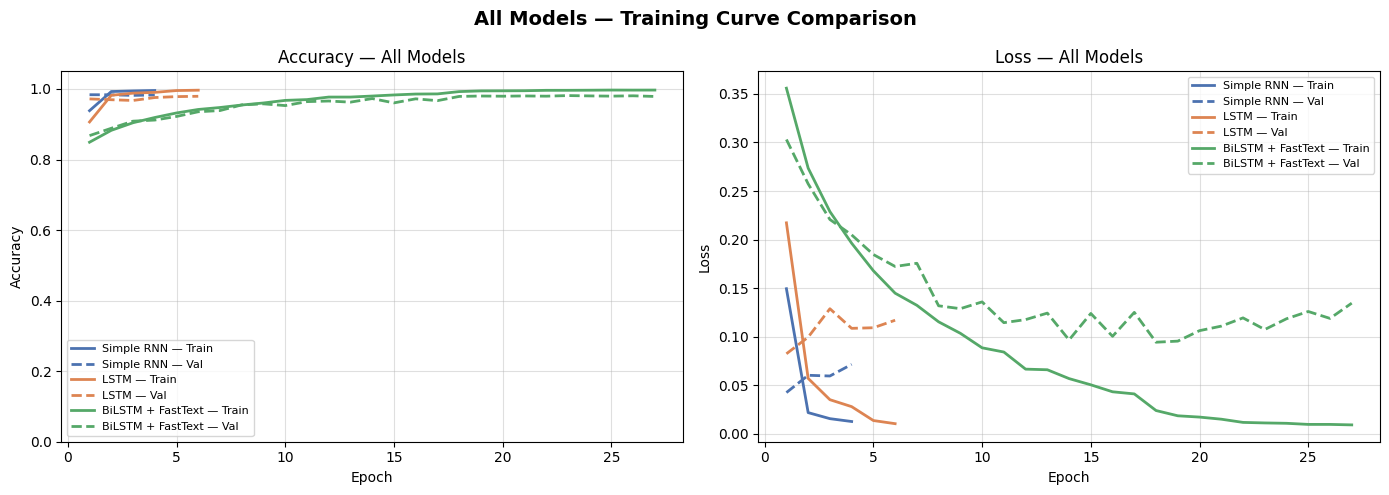

Performance Summary:
  Simple RNN  best val acc : 0.9837
  LSTM        best val acc : 0.9793
  BiLSTM+FT   best val acc : 0.9813
BiLSTM + FastText performs best — pretrained embeddings provide rich word representations.
LSTM > RNN because LSTM handles long-range dependencies better via gating mechanisms.


In [ ]:
# ── Compare all 3 models training curves on one figure
figure, chart_axes = plt.subplots(1, 2, figsize=(14, 5))
figure.suptitle('All Models — Training Curve Comparison', fontsize=14, fontweight='bold')

colour_palette = ['#4C72B0', '#DD8452', '#55A868']
model_titles   = ['Simple RNN', 'LSTM', 'BiLSTM + FastText']
history_objs   = [rnn_history, lstm_history, bilstm_history]

# Accuracy comparison
acc_ax = chart_axes[0]
for hist_obj, title, colour in zip(history_objs, model_titles, colour_palette):
    epoch_nums = range(1, len(hist_obj.history['accuracy']) + 1)
    acc_ax.plot(epoch_nums, hist_obj.history['accuracy'],
                color=colour, lw=2, label=f'{title} — Train')
    acc_ax.plot(epoch_nums, hist_obj.history['val_accuracy'],
                color=colour, lw=2, ls='--', label=f'{title} — Val')
acc_ax.set_title('Accuracy — All Models')
acc_ax.set_xlabel('Epoch'); acc_ax.set_ylabel('Accuracy')
acc_ax.set_ylim(0, 1.05); acc_ax.legend(fontsize=8); acc_ax.grid(True, alpha=0.4)

# Loss comparison
loss_ax = chart_axes[1]
for hist_obj, title, colour in zip(history_objs, model_titles, colour_palette):
    epoch_nums = range(1, len(hist_obj.history['loss']) + 1)
    loss_ax.plot(epoch_nums, hist_obj.history['loss'],
                 color=colour, lw=2, label=f'{title} — Train')
    loss_ax.plot(epoch_nums, hist_obj.history['val_loss'],
                 color=colour, lw=2, ls='--', label=f'{title} — Val')
loss_ax.set_title('Loss — All Models')
loss_ax.set_xlabel('Epoch'); loss_ax.set_ylabel('Loss')
loss_ax.legend(fontsize=8); loss_ax.grid(True, alpha=0.4)

plt.tight_layout(); plt.show()

print('Performance Summary:')
print(f'  Simple RNN  best val acc : {max(rnn_history.history["val_accuracy"]):.4f}')
print(f'  LSTM        best val acc : {max(lstm_history.history["val_accuracy"]):.4f}')
print(f'  BiLSTM+FT   best val acc : {max(bilstm_history.history["val_accuracy"]):.4f}')
print('BiLSTM + FastText performs best — pretrained embeddings provide rich word representations.')
print('LSTM > RNN because LSTM handles long-range dependencies better via gating mechanisms.')


## 12 · Error Analysis

In [ ]:
# Misclassified examples from BiLSTM model
raw_confidence = bilstm_network.predict(X_test_seq, verbose=0).flatten()
predicted_labels = (raw_confidence >= 0.5).astype(int)

error_indices = np.where(predicted_labels != y_test_raw)[0]
print(f'Misclassified: {len(error_indices)} out of {len(y_test_raw)} samples')
print()

idx_to_word = {v: k for k, v in sequence_tokenizer.word_index.items()}

for sample_num, err_idx in enumerate(error_indices[:3], start=1):
    decoded_tokens = [idx_to_word.get(t, '') for t in X_test_seq[err_idx] if t != 0]
    print(f'Example {sample_num}:')
    print(f'  Tweet      : {" ".join(decoded_tokens[:20])}')
    print(f'  True Label : {y_test_raw[err_idx]}')
    print(f'  Predicted  : {predicted_labels[err_idx]}')
    print(f'  Confidence : {raw_confidence[err_idx]:.3f}')
    print()

print('Possible reasons for errors:')
print('  - Short ambiguous tweets with limited context')
print('  - Sarcasm or implicit bias not captured by the model')
print('  - OOV (out-of-vocabulary) words reducing model signal')


Misclassified: 4528 out of 6393 samples

Example 1:
  Tweet      : fab amp interesting day <OOV> <OOV> quiet place <OOV> <OOV> emea region meeting
  True Label : 0
  Predicted  : 1
  Confidence : 0.506

Example 2:
  Tweet      : baby hudson baby <OOV> blanket pink <OOV> bouncingbaby
  True Label : 0
  Predicted  : 1
  Confidence : 0.509

Example 3:
  Tweet      : busy behind scene last week working something special
  True Label : 0
  Predicted  : 1
  Confidence : 0.501

Possible reasons for errors:
  - Short ambiguous tweets with limited context
  - Sarcasm or implicit bias not captured by the model
  - OOV (out-of-vocabulary) words reducing model signal


## 13 · Generate Predictions on Test Set

In [ ]:
holdout_seqs  = sequence_tokenizer.texts_to_sequences(test_data['processed_tweet'].values)
holdout_padded = pad_sequences(holdout_seqs, maxlen=SEQUENCE_LENGTH,
                               padding='post', truncating='post')

holdout_probs  = bilstm_network.predict(holdout_padded, verbose=0).flatten()
holdout_labels = (holdout_probs >= 0.5).astype(int)

output_df = pd.DataFrame({'id': test_data['id'], 'label': holdout_labels})
output_df.to_csv('submission_predictions.csv', index=False)

print('Predictions saved to submission_predictions.csv')
print(f'Predicted distribution: {Counter(holdout_labels)}')
output_df.head(10)

Predictions saved to submission_predictions.csv
Predicted distribution: Counter({1: 12460, 0: 4737})


,id,label
0,31963,1
1,31964,0
2,31965,0
3,31966,1
4,31967,1
5,31968,0
6,31969,1
7,31970,1
8,31971,1
9,31972,1


## 14 · Gradio Real-Time Demo

In [ ]:
!pip install gradio --quiet


In [ ]:
import gradio as gr

SENTIMENT_LABELS = {0: '  Not Racist / Sexist', 1: '  Racist / Sexist'}

def classify_user_tweet(user_input):
    """Preprocess and classify a user-entered tweet."""
    preprocessed = clean_single_tweet(user_input)
    token_seq    = sequence_tokenizer.texts_to_sequences([preprocessed])
    padded_seq   = pad_sequences(token_seq, maxlen=SEQUENCE_LENGTH,
                                  padding='post', truncating='post')
    confidence   = float(bilstm_network.predict(padded_seq, verbose=0)[0][0])
    prediction   = int(confidence >= 0.5)
    return (
        f"Prediction  : {SENTIMENT_LABELS[prediction]}\n"
        f"Confidence  : {confidence * 100:.1f}% (probability of racist/sexist)"
    )

tweet_app = gr.Interface(
    fn=classify_user_tweet,
    inputs=gr.Textbox(lines=3, placeholder='Type a tweet here …', label='Input Tweet'),
    outputs=gr.Textbox(label='Classification Result'),
    title=' Racist / Sexist Tweet Classifier',
    description='Powered by BiLSTM + FastText embeddings. Type a tweet to classify it.',
    examples=[
        ['I love spending time with my family #weekend'],
        ['Women should stay in the kitchen and not in the workplace'],
        ['Great game tonight! #basketball #sports']
    ],
    theme='soft'
)
tweet_app.launch(share=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>